# Experiment 3 — Width ($m$) and Depth ($L$) Analysis

Answers the two questions of the experiment plan:

- **Q-depth (complex data):** does adding layers ($L>1$) help on *hard* data that may require sequential
  feature extraction, and does it combine with stacking ($m>1$)?
- **Q-width (large $n$):** does increasing $m$ help, or does giving each SVM plenty of data make it
  redundant? Does adding layers help in the large-$n$ regime when combined with $m>1$?

The notebook loads the merged CSV (feeding + flat-baselines + width/depth runs), is **schema-robust**
(detects `macro_f1`, `auc`, `mean_cos_sim`, `split_id` if present), separates the runs by `exp_id`,
and builds focused tables per question plus the flat-baseline references (arc-cosine same-kernel control
and RBF). Conclusions are drawn only from the aggregated multi-seed results.

In [7]:
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
pd.set_option("display.width",180); pd.set_option("display.max_columns",60)
CSV = "../results/3_exp_width_depth_scenarios2.csv"   # adjust if your merged file has another name

## 1. Load (schema-robust) and tag rows

Derives `arm`/`m`/`L` from the `model` string when needed, identifies the flat baselines
(`flat_arccosine`, `flat_rbf_*`, `RBF_SVM_shallow_ref`) and the width/depth architecture rows,
and keeps whichever metric columns exist.

In [8]:
def load(path=CSV):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    # derive arm/m/L from model when not already explicit
    df["arm"] = df["model"].astype(str).str.replace(r"_m\d+_L\d+$","",regex=True)
    if "m" not in df or df["m"].isna().all():
        df["m"] = pd.to_numeric(df["model"].str.extract(r"_m(\d+)_L")[0], errors="coerce")
    if "L" not in df or df["L"].isna().all():
        df["L"] = pd.to_numeric(df["model"].str.extract(r"_L(\d+)$")[0], errors="coerce")
    for c in ["n_total","n_train","d","n_classes","m","L","P","acc","time_s",
              "macro_f1","auc","mean_cos_sim"]:
        if c in df: df[c] = pd.to_numeric(df[c], errors="coerce")
    # which optional columns are present?
    METRICS = [c for c in ["acc","macro_f1","auc"] if c in df.columns]
    # role: flat baseline vs architecture
    def role(r):
        a = str(r["arm"]); k = str(r.get("kernel",""))
        if a in ("flat_arccosine",): return "flat_arccosine"
        if a in ("flat_rbf_exact","flat_rbf_rff") or a=="RBF_SVM_shallow_ref": return "flat_rbf"
        return "architecture"
    df["role"] = df.apply(role, axis=1)
    return df, METRICS

df, METRICS = load()
print("rows:", len(df), "| metrics present:", METRICS)
print("exp_ids:", df.exp_id.unique().tolist())
print("roles:", df.role.value_counts().to_dict())
print("datasets:", sorted(df.dataset.unique()))
print("m:", sorted(df.m.dropna().unique()), "| L:", sorted(df.L.dropna().unique()))
df.head()

rows: 1005 | metrics present: ['acc']
exp_ids: ['exp_width_depth_scenarios2', 'exp_flat_baselines']
roles: {'architecture': 729, 'flat_rbf': 168, 'flat_arccosine': 108}
datasets: ['CoverType', 'Digits8x8', 'HIGGS', 'MNIST', 'Optdigits', 'Satimage', 'SynthComp', 'SynthMC_blobs', 'SynthMC_nonlinear']
m: [np.int64(0), np.int64(1), np.int64(5), np.int64(10), np.int64(20)] | L: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,exp_id,dataset,n_total,n_train,n_test,d,n_classes,model,kernel,L,m,P,split_id,acc,time_s,timestamp,arm,role
0,exp_width_depth_scenarios2,SynthComp,1000,1000,1200,24,2,RBF_SVM_shallow_ref,rbf,0,0,0,NaN,0.5000,NaN,2026-06-15T20:35:27.469778,RBF_SVM_shallow_ref,flat_rbf
1,exp_width_depth_scenarios2,SynthComp,1000,1000,1200,24,2,RBF_SVM_shallow_ref,rbf,0,0,0,NaN,0.5092,NaN,2026-06-15T20:35:27.543295,RBF_SVM_shallow_ref,flat_rbf
2,exp_width_depth_scenarios2,SynthComp,1000,1000,1200,24,2,RBF_SVM_shallow_ref,rbf,0,0,0,NaN,0.5217,NaN,2026-06-15T20:35:27.619688,RBF_SVM_shallow_ref,flat_rbf
3,exp_width_depth_scenarios2,SynthComp,1000,1000,1200,24,2,C_splitdata_m1_L1,arc_cosine,1,1,1000,NaN,0.5250,0.26,2026-06-15T20:35:27.916184,C_splitdata,architecture
4,exp_width_depth_scenarios2,SynthComp,1000,1000,1200,24,2,C_splitdata_m1_L1,arc_cosine,1,1,1000,NaN,0.4875,0.23,2026-06-15T20:35:28.178815,C_splitdata,architecture


## 2. Scenario tags (complexity × scale)

The questions are about *regimes*, so we tag each dataset by **complexity** (easy/medium/hard) and
**scale** (small/medium/large). Hardness is judged by how far the flat kernel SVM is from the ceiling;
scale by $n$. Adjust the dictionary if you want different groupings.

In [9]:
SCENARIO = {   # (complexity, scale) — edit freely
    "SynthComp":        ("probe",  "small"),
    "SynthMC_blobs":    ("easy",   "small"),
    "SynthMC_nonlinear":("hard",   "small"),
    "Digits8x8":        ("easy",   "small"),
    "Optdigits":        ("easy",   "small"),
    "Satimage":         ("medium", "small"),
    "MNIST":            ("medium", "medium"),
    "HIGGS":            ("hard",   "large"),
    "CoverType":        ("hard",   "large"),
}
df["complexity"] = df.dataset.map(lambda d: SCENARIO.get(d,("?","?"))[0])
df["scale"]      = df.dataset.map(lambda d: SCENARIO.get(d,("?","?"))[1])
print(df.groupby(["dataset","complexity","scale"]).size().rename("rows").reset_index().to_string(index=False))

          dataset complexity  scale  rows
        CoverType       hard  large   123
        Digits8x8       easy  small   153
            HIGGS       hard  large   123
            MNIST     medium medium   135
        Optdigits       easy  small   153
         Satimage     medium  small   117
        SynthComp      probe  small    51
    SynthMC_blobs       easy  small    75
SynthMC_nonlinear       hard  small    75


## 3. Aggregate over seeds

Mean ± std for every metric, per (dataset, arm, m, L, n). The architecture rows and the flat baselines
are aggregated the same way so they can be compared directly.

In [10]:
def agg(d):
    base = ["dataset","complexity","scale","role","arm","m","L","n_train"]
    aggd = {met:["mean","std"] for met in METRICS}
    aggd["acc"]=["mean","std","size"]
    g = d.groupby(base, dropna=False).agg(aggd)
    g.columns = ["_".join(c) for c in g.columns]
    g = g.rename(columns={"acc_size":"seeds"}).reset_index()
    for met in METRICS:
        g[f"{met}_std"] = g[f"{met}_std"].fillna(0.0)
    return g
A = agg(df)
print(len(A),"aggregated cells"); A.head()

308 aggregated cells


,dataset,complexity,scale,role,arm,m,L,n_train,acc_mean,acc_std,seeds
0,CoverType,hard,large,architecture,C_splitdata,1,1,2000,0.703267,0.001222,3
1,CoverType,hard,large,architecture,C_splitdata,1,1,10000,0.763867,0.003859,3
2,CoverType,hard,large,architecture,C_splitdata,1,1,50000,0.785100,0.001664,3
3,CoverType,hard,large,architecture,C_splitdata,1,2,2000,0.699933,0.002309,3
4,CoverType,hard,large,architecture,C_splitdata,1,2,10000,0.766667,0.004517,3


## 4. Flat-baseline reference table

The same-kernel control (`flat_arccosine`) and the RBF reference, per dataset and $n$. Any gain of the
deep/wide architecture must be read against these: beating `flat_arccosine` isolates the architecture's
contribution (kernel held fixed).

In [11]:
flat = A[A.role.isin(["flat_arccosine","flat_rbf"])].copy()
def flat_table(metric="acc"):
    p = flat.pivot_table(index=["dataset","n_train"], columns="role",
                         values=f"{metric}_mean")
    return p.round(4)
for met in METRICS:
    print(f"\n=== flat baselines — {met} ==="); display(flat_table(met))


=== flat baselines — acc ===


role                       flat_arccosine  flat_rbf
dataset           n_train                          
CoverType         2000             0.7186    0.7052
                  10000            0.7633    0.7393
                  50000            0.7798    0.7564
Digits8x8         500              0.9700    0.9640
                  1000             0.9793    0.9773
                  1297             0.9787    0.9800
HIGGS             2000             0.6067    0.6393
                  10000            0.6396    0.6693
                  50000            0.6705    0.6784
MNIST             2000             0.8831    0.8936
                  10000            0.9220    0.9391
                  50000            0.9472    0.9353
Optdigits         500              0.9520    0.9508
                  2000             0.9781    0.9739
                  3823             0.9864    0.9825
Satimage          500              0.8636    0.8655
                  2000             0.8906    0.8813
                  4435             0.9101    0.8942
SynthComp         1000                NaN    0.5103
                  3000                NaN    0.5094
SynthMC_blobs     1000             0.8425    0.8861
                  3000             0.8603    0.9136
SynthMC_nonlinear 1000             0.5317    0.5642
                  3000             0.6269    0.6334

## 5. Q-WIDTH — does increasing $m$ help, and does it fade at large $n$?

For each (dataset, $n$) we take the best $L$ and compare the best $m>1$ against $m=1$. The hypothesis:
width helps as a regulariser at small/medium $n$ and fades at large $n$ (each SVM already gets enough
data). The `gain_vs_flat_arccos` column shows the architecture's gain over the same-kernel flat SVM.

In [12]:
arch = A[A.role=="architecture"].copy()
def width_table(metric="acc"):
    rows=[]
    for (ds,n),g in arch.groupby(["dataset","n_train"]):
        gg = g.sort_values(f"{metric}_mean", ascending=False)
        m1 = g[g.m==1]
        mgt = g[g.m>1]
        if m1.empty or mgt.empty: continue
        b1 = m1.loc[m1[f"{metric}_mean"].idxmax()]
        bm = mgt.loc[mgt[f"{metric}_mean"].idxmax()]
        fa = flat[(flat.dataset==ds)&(flat.n_train==n)&(flat.role=="flat_arccosine")]
        fa_v = fa[f"{metric}_mean"].max() if not fa.empty else np.nan
        rows.append(dict(dataset=ds, scale=g.scale.iloc[0], complexity=g.complexity.iloc[0],
            n=int(n), m1=round(b1[f"{metric}_mean"],4),
            best_mgt1=round(bm[f"{metric}_mean"],4), best_m=int(bm.m), best_L=int(bm.L),
            gain_m=round(bm[f"{metric}_mean"]-b1[f"{metric}_mean"],4),
            sig=bool(bm[f"{metric}_mean"]-b1[f"{metric}_mean"] > bm[f"{metric}_std"]),
            gain_vs_flat_arccos=(round(bm[f"{metric}_mean"]-fa_v,4) if not np.isnan(fa_v) else np.nan)))
    return pd.DataFrame(rows).sort_values(["scale","dataset","n"])
for met in METRICS:
    print(f"\n=== WIDTH effect — {met} (best m>1 vs m=1) ==="); display(width_table(met))


=== WIDTH effect — acc (best m>1 vs m=1) ===


,dataset,scale,complexity,n,m1,best_mgt1,best_m,best_L,gain_m,sig,gain_vs_flat_arccos
0,CoverType,large,hard,2000,0.7033,0.7080,10,2,0.0047,True,-0.0106
1,CoverType,large,hard,10000,0.7667,0.7673,5,3,0.0007,False,0.0041
2,CoverType,large,hard,50000,0.7954,0.8073,5,3,0.0119,True,0.0275
6,HIGGS,large,hard,2000,0.5840,0.6293,10,1,0.0453,True,0.0226
7,HIGGS,large,hard,10000,0.6357,0.6504,20,1,0.0148,True,0.0109
8,HIGGS,large,hard,50000,0.6717,0.6711,5,1,-0.0006,False,0.0005
9,MNIST,medium,medium,2000,0.8874,0.9235,10,3,0.0361,True,0.0404
10,MNIST,medium,medium,10000,0.9256,0.9541,10,2,0.0285,True,0.0320
11,MNIST,medium,medium,50000,0.9521,0.9709,10,2,0.0189,True,0.0238
3,Digits8x8,small,easy,500,0.9700,0.9613,5,2,-0.0087,False,-0.0087


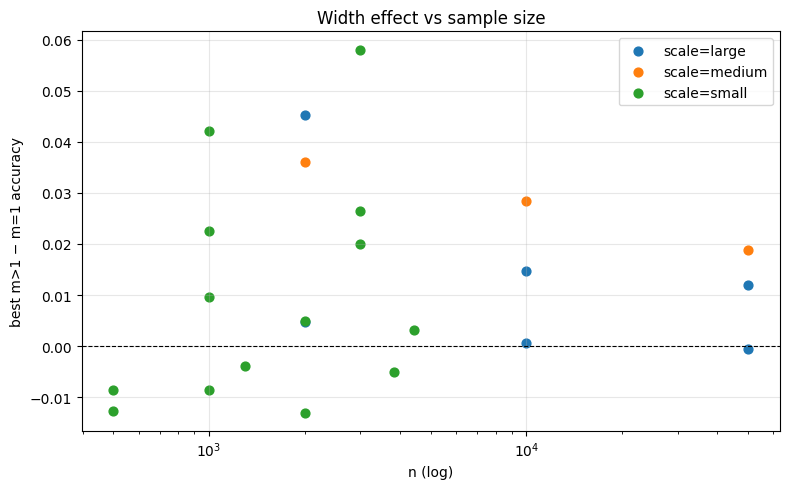

In [13]:
# Plot: width gain vs n, coloured by scale
wt = width_table("acc")
fig,ax=plt.subplots(figsize=(8,5))
for sc,g in wt.groupby("scale"):
    g=g.sort_values("n"); ax.scatter(g.n,g.gain_m,label=f"scale={sc}",s=40)
ax.axhline(0,color="k",lw=.8,ls="--"); ax.set_xscale("log")
ax.set_xlabel("n (log)"); ax.set_ylabel("best m>1 − m=1 accuracy")
ax.set_title("Width effect vs sample size"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Q-DEPTH — does adding layers help, especially on hard data?

For each (dataset, $m$) we measure the change from $L=1$ to the best $L$, then summarise by **complexity**.
The hypothesis: depth helps most on *hard* data (sequential feature extraction) and little on easy data.

In [14]:
def depth_table(metric="acc"):
    rows=[]
    piv = arch.pivot_table(index=["dataset","complexity","scale","m","n_train"],
                           columns="L", values=f"{metric}_mean")
    Ls = [c for c in piv.columns]
    for idx,r in piv.iterrows():
        ds,cx,sc,m,n = idx
        if 1 not in r or np.isnan(r.get(1,np.nan)): continue
        avail = [L for L in Ls if not np.isnan(r.get(L,np.nan))]
        if len(avail)<2: continue
        bestL = max(avail, key=lambda L: r[L])
        rows.append(dict(dataset=ds,complexity=cx,scale=sc,m=int(m),n=int(n),
            L1=round(r[1],4), bestL=int(bestL), bestL_acc=round(r[bestL],4),
            depth_gain=round(r[bestL]-r[1],4)))
    return pd.DataFrame(rows)
dt = depth_table("acc")
print("=== DEPTH effect per (dataset,m,n): change from L=1 to best L ===")
display(dt.sort_values("depth_gain",ascending=False).head(15))
print("\n=== DEPTH effect summarised by COMPLEXITY ===")
display(dt.groupby("complexity")["depth_gain"].agg(["mean","median","max","count"]).round(4))
print("\n=== DEPTH effect summarised by SCALE ===")
display(dt.groupby("scale")["depth_gain"].agg(["mean","median","max","count"]).round(4))

=== DEPTH effect per (dataset,m,n): change from L=1 to best L ===


,dataset,complexity,scale,m,n,L1,bestL,bestL_acc,depth_gain
55,Optdigits,easy,small,20,500,0.8983,3,0.9306,0.0323
8,CoverType,hard,large,10,50000,0.7744,3,0.8055,0.0311
75,SynthMC_blobs,easy,small,10,3000,0.8808,3,0.9103,0.0295
10,CoverType,hard,large,20,50000,0.7716,3,0.8009,0.0293
5,CoverType,hard,large,5,50000,0.7785,3,0.8073,0.0288
73,SynthMC_blobs,easy,small,5,1000,0.8556,2,0.8842,0.0286
80,SynthMC_nonlinear,hard,small,10,3000,0.5986,2,0.6236,0.0250
21,Digits8x8,easy,small,20,1000,0.9447,3,0.9673,0.0227
20,Digits8x8,easy,small,20,500,0.9200,2,0.9420,0.0220
74,SynthMC_blobs,easy,small,5,3000,0.8797,2,0.9011,0.0214



=== DEPTH effect summarised by COMPLEXITY ===


,mean,median,max,count
complexity,,,,
easy,0.0118,0.0100,0.0323,29
hard,0.0075,0.0002,0.0311,27
medium,0.0039,0.0028,0.0135,20
probe,0.0068,0.0056,0.0158,5



=== DEPTH effect summarised by SCALE ===


,mean,median,max,count
scale,,,,
large,0.0072,0.0002,0.0311,22
medium,0.0031,0.0024,0.0122,12
small,0.0098,0.0067,0.0323,47


/tmp/ipykernel_478528/1845109782.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp=ax.boxplot(data,labels=present,showmeans=True,widths=0.6)


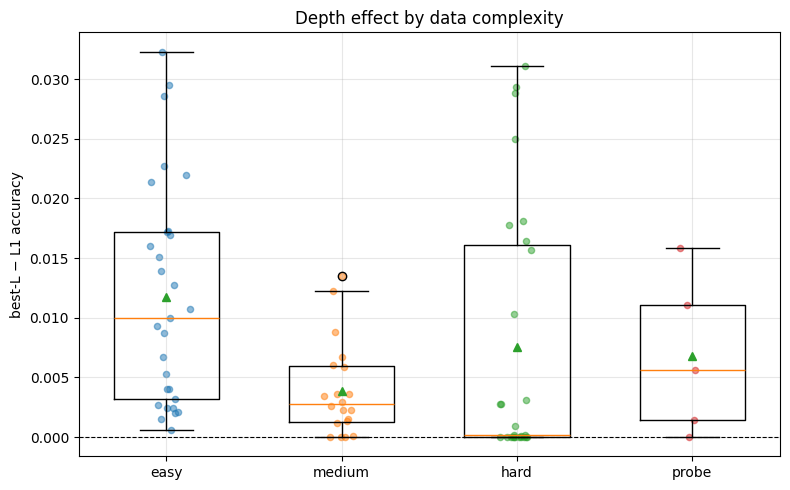

In [15]:
# Plot: depth gain by complexity (box/strip)
fig,ax=plt.subplots(figsize=(8,5))
order=["easy","medium","hard","probe"]
present=[c for c in order if c in dt.complexity.unique()]
data=[dt[dt.complexity==c].depth_gain.values for c in present]
ax.axhline(0,color="k",lw=.8,ls="--")
bp=ax.boxplot(data,labels=present,showmeans=True,widths=0.6)
for i,c in enumerate(present):
    y=dt[dt.complexity==c].depth_gain.values; x=np.random.normal(i+1,0.05,len(y))
    ax.scatter(x,y,alpha=0.5,s=20)
ax.set_ylabel("best-L − L1 accuracy"); ax.set_title("Depth effect by data complexity")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. Q-INTERACTION — does depth help *more* when $m$ is larger?

The plan asks specifically whether depth combined with width helps in the large-$n$ regime. We pivot the
depth gain by $m$, and separately look at the large-$n$ datasets, to see whether the $L$-gain grows with $m$.

In [16]:
print("=== depth gain (best L − L1) by m, averaged over datasets ===")
display(dt.groupby("m")["depth_gain"].agg(["mean","median","count"]).round(4))
print("\n=== same, restricted to LARGE-scale datasets ===")
dl = dt[dt.scale=="large"]
if not dl.empty:
    display(dl.groupby("m")["depth_gain"].agg(["mean","median","count"]).round(4))
print("\n=== full m×L accuracy grid for the large-n hard datasets (the key cases) ===")
for ds in arch[arch.scale=="large"].dataset.unique():
    g=arch[arch.dataset==ds]
    piv=g.pivot_table(index=["n_train","m"],columns="L",values="acc_mean").round(4)
    print(f"\n--- {ds} ---"); display(piv)

=== depth gain (best L − L1) by m, averaged over datasets ===


,mean,median,count
m,,,
1,0.0026,0.0022,24
5,0.0075,0.0036,23
10,0.0115,0.0117,20
20,0.0136,0.0154,14



=== same, restricted to LARGE-scale datasets ===


,mean,median,count
m,,,
1,0.0024,0.0006,6
5,0.0079,0.0001,6
10,0.0087,0.0016,6
20,0.0112,0.0078,4



=== full m×L accuracy grid for the large-n hard datasets (the key cases) ===

--- CoverType ---


L                1       2       3
n_train m                         
2000    1   0.7033  0.6999  0.6972
        5   0.7058  0.7059  0.7060
        10  0.7049  0.7080  0.7063
10000   1   0.7639  0.7667  0.7666
        5   0.7492  0.7647  0.7673
        10  0.7466  0.7610  0.7645
        20  0.7457  0.7580  0.7614
50000   1   0.7851  0.7931  0.7954
        5   0.7785  0.8001  0.8073
        10  0.7744  0.7946  0.8055
        20  0.7716  0.7908  0.8009


--- HIGGS ---


L                1       2       3
n_train m                         
2000    1   0.5837  0.5840  0.5838
        5   0.6202  0.6157  0.6143
        10  0.6293  0.6246  0.6174
10000   1   0.6355  0.6355  0.6357
        5   0.6323  0.6301  0.6272
        10  0.6445  0.6375  0.6318
        20  0.6504  0.6412  0.6339
50000   1   0.6708  0.6716  0.6717
        5   0.6711  0.6695  0.6701
        10  0.6703  0.6644  0.6612
        20  0.6696  0.6626  0.6543

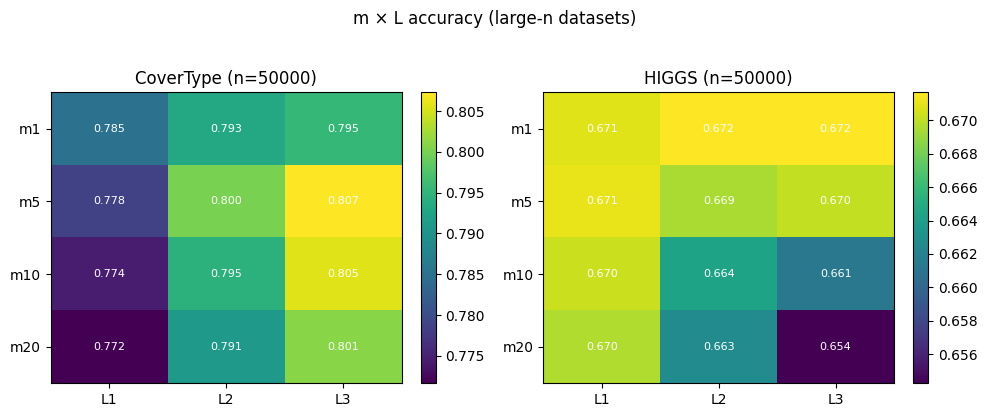

In [17]:
# Heatmap-style: m x L mean accuracy for each large-n dataset (visual interaction check)
larges=[ds for ds in arch[arch.scale=="large"].dataset.unique()]
if larges:
    fig,axes=plt.subplots(1,len(larges),figsize=(5*len(larges),4),squeeze=False)
    for j,ds in enumerate(larges):
        g=arch[(arch.dataset==ds)]
        # use the largest n available
        nmax=g.n_train.max(); gg=g[g.n_train==nmax]
        piv=gg.pivot_table(index="m",columns="L",values="acc_mean")
        ax=axes[0][j]; im=ax.imshow(piv.values,aspect="auto",cmap="viridis")
        ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"L{int(c)}" for c in piv.columns])
        ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([f"m{int(i)}" for i in piv.index])
        ax.set_title(f"{ds} (n={int(nmax)})")
        for a in range(piv.shape[0]):
            for b in range(piv.shape[1]):
                ax.text(b,a,f"{piv.values[a,b]:.3f}",ha="center",va="center",
                        color="white",fontsize=8)
        fig.colorbar(im,ax=ax,fraction=0.046)
    fig.suptitle("m × L accuracy (large-n datasets)",y=1.03)
    plt.tight_layout(); plt.show()

## 8. The compositional probe (SynthComp / SynthMC)

What accuracy the synthetic compositional targets reach, and whether depth changes it. (Outcome left open —
read directly from the table; if depth does not move accuracy, that is itself a finding about the greedy
projection.)

In [18]:
probe = arch[arch.dataset.str.startswith('Synth')]
if not probe.empty:
    for ds in probe.dataset.unique():
        g=probe[probe.dataset==ds]
        # n_classes from the raw df (not carried into the aggregate)
        K=int(df[df.dataset==ds]['n_classes'].iloc[0])
        piv=g.pivot_table(index=['n_train','m'],columns='L',values='acc_mean').round(4)
        print(f'\n--- {ds} (chance approx 1/{K} = {1/K:.3f}) ---')
        display(piv)
else:
    print('no synthetic probe rows found')



--- SynthComp (chance approx 1/2 = 0.500) ---


L                1       2       3
n_train m                         
1000    1   0.5089  0.5086  0.5086
        5   0.5075  0.5147  0.5186
3000    1   0.4894  0.4906  0.4908
        5   0.5053  0.5097  0.5109
        10  0.4905  0.5008  0.5064


--- SynthMC_blobs (chance approx 1/6 = 0.167) ---


L                1       2       3
n_train m                         
1000    1   0.8333  0.8414  0.8420
        5   0.8556  0.8842  0.8836
3000    1   0.8422  0.8522  0.8506
        5   0.8797  0.9011  0.8997
        10  0.8808  0.9080  0.9103


--- SynthMC_nonlinear (chance approx 1/5 = 0.200) ---


L                1       2       3
n_train m                         
1000    1   0.5189  0.5145  0.5161
        5   0.5250  0.5414  0.5286
3000    1   0.5944  0.5972  0.5908
        5   0.6114  0.6097  0.6014
        10  0.5986  0.6236  0.6183

## 9. Architecture vs flat baselines — the headline comparison

Best architecture configuration (over $m,L$) per (dataset, $n$) against `flat_arccosine` (same kernel)
and `flat_rbf`. This is the table that says whether the depth/width machinery earns its complexity.

In [19]:
def headline(metric="acc"):
    rows=[]
    for (ds,n),g in arch.groupby(["dataset","n_train"]):
        best=g.loc[g[f"{metric}_mean"].idxmax()]
        fa=flat[(flat.dataset==ds)&(flat.n_train==n)&(flat.role=="flat_arccosine")]
        fr=flat[(flat.dataset==ds)&(flat.n_train==n)&(flat.role=="flat_rbf")]
        rows.append(dict(dataset=ds,scale=g.scale.iloc[0],complexity=g.complexity.iloc[0],n=int(n),
            best_arch=round(best[f"{metric}_mean"],4), m=int(best.m), L=int(best.L),
            flat_arccos=(round(fa[f"{metric}_mean"].max(),4) if not fa.empty else np.nan),
            flat_rbf=(round(fr[f"{metric}_mean"].max(),4) if not fr.empty else np.nan)))
    out=pd.DataFrame(rows).sort_values(["scale","dataset","n"])
    out["arch_minus_arccos"]=(out.best_arch-out.flat_arccos).round(4)
    return out
for met in METRICS:
    print(f"\n=== headline — {met} ==="); display(headline(met))


=== headline — acc ===


,dataset,scale,complexity,n,best_arch,m,L,flat_arccos,flat_rbf,arch_minus_arccos
0,CoverType,large,hard,2000,0.7080,10,2,0.7186,0.7052,-0.0106
1,CoverType,large,hard,10000,0.7673,5,3,0.7633,0.7393,0.0040
2,CoverType,large,hard,50000,0.8073,5,3,0.7798,0.7564,0.0275
6,HIGGS,large,hard,2000,0.6293,10,1,0.6067,0.6393,0.0226
7,HIGGS,large,hard,10000,0.6504,20,1,0.6396,0.6693,0.0108
8,HIGGS,large,hard,50000,0.6717,1,3,0.6705,0.6784,0.0012
9,MNIST,medium,medium,2000,0.9235,10,3,0.8831,0.8936,0.0404
10,MNIST,medium,medium,10000,0.9541,10,2,0.9220,0.9391,0.0321
11,MNIST,medium,medium,50000,0.9709,10,2,0.9472,0.9353,0.0237
3,Digits8x8,small,easy,500,0.9700,1,3,0.9700,0.9640,0.0000


## 10. Findings (fill from the tables)

- **Q-width:** §5 — is best $m>1$ > $m=1$, and does `gain_m` shrink as $n$ grows (regulariser fading)?
- **Q-depth on hard data:** §6 — is `depth_gain` larger for `complexity=hard` than `easy`?
- **Q-interaction (large n):** §7 — does the depth gain grow with $m$ on the large-$n$ datasets?
- **Probe:** §8 — does depth move the synthetic-compositional accuracy at all?
- **Earns its complexity:** §9 — does the best architecture beat `flat_arccosine` (same kernel)?

**Caveats:** report only gains exceeding the seed std (`sig`); note `macro_f1` vs `acc` gaps on imbalanced
multiclass (CoverType); CoverType/HIGGS large-$n$ cells may be cost-capped; the synthetic probe outcome is
descriptive, not assumed.